# 03 — Entrenamiento del modelo obra_v4

**Proyecto:** Sistema de Detección de Riesgos de Corrupción en Obras Públicas mediante ML  
**Tesis:** Maestría en Inteligencia Artificial – UNI  
**Autor:** Fernando García Atúncar  
**Versión:** v2.0 — Sprint 2 (post decisiones D1–D3)

---

## Cambios respecto a v1.0

| Bloque | Cambio |
|--------|--------|
| PASO 1 | Lee desde `data/processed/dataset_obra_v4_model.parquet` |
| PASO 2 | Target corregido: `y_riesgo_obra` (4 niveles, D1) |
| PASO 4 | Agrega `StandardScaler` a pipeline numérico |
| PASO 4 | Agrega `LightGBM` como cuarto algoritmo |
| PASO 5 | Entrenamiento con 4 modelos + tabla comparativa |
| PASO 6 | Matriz de confusión con etiquetas correctas (4 clases) |
| PASO 7 | Feature importance con nombres limpios (sin prefijo `num__`) |
| PASO 8 | Cross Validation con intervalo de confianza por fold |
| PASO 9 | Hyperparameter tuning con `n_iter=50` y espacio ampliado |
| PASO 10 | Evaluación final con reporte por clase y etiquetas semánticas |
| PASO 11 | Guarda modelo, métricas y feature importance |
| PASO 12 | Gráficos finales con etiquetas de 4 clases |

---

## Dataset de entrada
```
data/processed/dataset_obra_v4_model.parquet
326 filas × 77 features + 1 target
```

## Target
```
y_riesgo_obra — 4 niveles (Decisión D1)
  0 → Sin Riesgo              (32 obs,  9.8%)
  1 → Bajamente Riesgosa      (52 obs, 16.0%)
  2 → Med/Alt Riesgosa        (94 obs, 28.8%)
  3 → Extremadamente Riesgosa (148 obs, 45.4%)
```


---
## PASO 0 — Imports y configuración

In [1]:
# ============================================================
# PASO 0 — IMPORTS
# ============================================================

from pathlib import Path
import warnings
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from scipy.stats import randint

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("⚠️  LightGBM no instalado — se omitirá del entrenamiento")
    print("   Instalar con: pip install lightgbm")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

BASE_DIR  = Path(r"C:\IA_Investigacion\Deteccion_Corrupcion")
DATA_PROC = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models" / "obra_v4"
FIG_DIR   = BASE_DIR / "reports" / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Etiquetas semánticas de las 4 clases
ETIQUETAS = {
    0: "Sin Riesgo",
    1: "Bajamente Riesgosa",
    2: "Med/Alt Riesgosa",
    3: "Extrem. Riesgosa",
}
CLASS_LABELS = [ETIQUETAS[i] for i in sorted(ETIQUETAS)]

print("✅ Imports OK")
print(f"   LightGBM disponible: {LGBM_AVAILABLE}")


✅ Imports OK
   LightGBM disponible: True


---
## PASO 1 — Carga del dataset

In [2]:
# ============================================================
# PASO 1 — CARGA DEL DATASET
# ============================================================

dataset_path = DATA_PROC / "dataset_obra_v4_model.parquet"

df = pd.read_parquet(dataset_path)

print("=" * 60)
print("DATASET CARGADO")
print("=" * 60)
print(f"Shape         : {df.shape}")
print(f"Target único  : {sorted(df['y_riesgo_obra'].unique())}")
print()
print("Distribución target:")
vc = df["y_riesgo_obra"].value_counts().sort_index()
for cls, cnt in vc.items():
    pct = cnt / len(df) * 100
    print(f"  Clase {cls} — {ETIQUETAS[cls]:25s}: {cnt:>3} ({pct:5.1f}%)")

print()
print("Columnas:")
for i, c in enumerate(df.columns, 1):
    print(f"  {i:02d}. {c}")


DATASET CARGADO
Shape         : (326, 79)
Target único  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Distribución target:
  Clase 0 — Sin Riesgo               :  32 (  9.8%)
  Clase 1 — Bajamente Riesgosa       :  52 ( 16.0%)
  Clase 2 — Med/Alt Riesgosa         :  94 ( 28.8%)
  Clase 3 — Extrem. Riesgosa         : 148 ( 45.4%)

Columnas:
  01. IDENTIFICADOR_OBRA
  02. ETAPA
  03. DIAS_PLAZO
  04. TOTAL_CONTROL_PREVIO
  05. TOTAL_CONTROL_SIMULTANEO
  06. TOTAL_CONTROL_POSTERIOR
  07. y_riesgo_obra
  08. obra_ctx_sector
  09. obra_ctx_nivel_gobierno
  10. obra_ctx_objeto_proceso
  11. obra_ctx_metodo_contratacion
  12. obra_ctx_departamento
  13. obra_monto_contractual_sum
  14. obra_monto_referencial_sum
  15. obra_monto_ofertado_prom_mean
  16. obra_n_contratos_ganados
  17. obra_n_participantes_mean
  18. obra_n_participantes_max
  19. obra_ratio_contractual_referencial
  20. obra_ahorro_absoluto
  21. obra_sobre_referencial
  22. obra_ratio_oferta_contrato
  23. obra_n_mi

---
## PASO 2 — Limpieza pre-modelo

In [3]:
# ============================================================
# PASO 2 — SEPARAR X / y
# ============================================================

TARGET = "y_riesgo_obra"

COLS_EXCLUIR = [
    "IDENTIFICADOR_OBRA",       # llave técnica
    "RIESGO_OBRA",              # target original sin mapear
    "RIESGO_DESCRIPCION_OBRA",  # texto del target — leakage
]

if TARGET not in df.columns:
    raise ValueError(f"❌ Target no encontrado: {TARGET}")

X = df.drop(columns=[c for c in COLS_EXCLUIR + [TARGET] if c in df.columns]).copy()
y = df[TARGET].astype(int).copy()

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"Clases  : {sorted(y.unique())}")


Shape X : (326, 77)
Shape y : (326,)
Clases  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [4]:
# ============================================================
# PASO 2.1 — VALIDACIÓN DE COLUMNAS Y NULOS
# ============================================================

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Numéricas   : {len(num_cols)}")
print(f"Categóricas : {len(cat_cols)}")

nulos = X.isna().sum().sort_values(ascending=False)
nulos_df = nulos[nulos > 0].to_frame("n_nulos")
nulos_df["pct"] = (nulos_df["n_nulos"] / len(X) * 100).round(1)

print(f"\nFeatures sin nulos    : {(nulos == 0).sum()}")
print(f"Features con <20% nul : {((nulos > 0) & (nulos/len(X) < 0.2)).sum()}")
print(f"Features con >20% nul : {(nulos/len(X) >= 0.2).sum()}  ← debe ser 0")

if len(nulos_df) > 0:
    print("\nDetalle nulos:")
    display(nulos_df)


Numéricas   : 71
Categóricas : 6

Features sin nulos    : 41
Features con <20% nul : 36
Features con >20% nul : 0  ← debe ser 0

Detalle nulos:


,n_nulos,pct
obra_monto_referencial_sum,2,0.6000
obra_monto_ofertado_prom_mean,2,0.6000
obra_monto_contractual_sum,2,0.6000
obra_n_contratos,2,0.6000
obra_n_participaciones,2,0.6000
obra_n_rucs_participantes,2,0.6000
obra_ratio_oferta_contrato,2,0.6000
obra_sobre_referencial,2,0.6000
obra_ahorro_absoluto,2,0.6000
obra_ratio_contractual_referencial,2,0.6000


In [5]:
# ============================================================
# PASO 2.2 — VALIDACIÓN ANTI-LEAKAGE
# ============================================================

FORBIDDEN = ["DNI", "RUC", "CODIGO_DNI", "CODIGO_RUC", "NOMBRE", "RAZON_SOCIAL"]

bad_cols = [
    col for col in X.columns
    if any(
        col.upper() == f or
        col.upper().startswith(f + "_") or
        col.upper().endswith("_" + f)
        for f in FORBIDDEN
    )
]

if bad_cols:
    raise ValueError(f"❌ Columnas prohibidas detectadas: {bad_cols}")
else:
    print("✅ Validación anti-leakage OK")


✅ Validación anti-leakage OK


---
## PASO 3 — Split estratificado train/test

In [6]:
# ============================================================
# PASO 3 — SPLIT TRAIN / TEST ESTRATIFICADO
# ============================================================

TEST_SIZE    = 0.20
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

# Verificar proporciones
dist = pd.DataFrame({
    "total_%":  y.value_counts(normalize=True).sort_index() * 100,
    "train_%":  y_train.value_counts(normalize=True).sort_index() * 100,
    "test_%":   y_test.value_counts(normalize=True).sort_index() * 100,
}).fillna(0).round(1)
dist.index = [ETIQUETAS[i] for i in dist.index]

print("\nProporción por clase (estratificación):")
display(dist)


X_train : (260, 77)
X_test  : (66, 77)

Proporción por clase (estratificación):


,total_%,train_%,test_%
Sin Riesgo,9.8000,10.0000,9.1000
Bajamente Riesgosa,16.0000,15.8000,16.7000
Med/Alt Riesgosa,28.8000,28.8000,28.8000
Extrem. Riesgosa,45.4000,45.4000,45.5000


---
## PASO 4 — Preprocesador

In [7]:
# ============================================================
# PASO 4 — PREPROCESADOR
# Pipeline numérico: imputa mediana + escala (StandardScaler)
# Pipeline categórico: imputa moda + OneHotEncoder
# ============================================================

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object","category","bool"]).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop",
)

print(f"✅ Preprocesador construido")
print(f"   Numéricas   : {len(num_cols)}")
print(f"   Categóricas : {len(cat_cols)}")


✅ Preprocesador construido
   Numéricas   : 71
   Categóricas : 6


---
## PASO 5 — Entrenamiento con 4 algoritmos

In [8]:
# ============================================================
# PASO 5 — DEFINICIÓN DE MODELOS
# ============================================================

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
}

if LGBM_AVAILABLE:
    models["LightGBM"] = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )

print(f"Modelos a entrenar: {list(models.keys())}")


Modelos a entrenar: ['RandomForest', 'GradientBoosting', 'LogisticRegression', 'LightGBM']


In [9]:
# ============================================================
# PASO 5.1 — ENTRENAMIENTO Y EVALUACIÓN EN TEST
# ============================================================

results      = []
trained_pipelines = {}

for name, clf in models.items():

    print(f"\n{'='*60}")
    print(f"ENTRENANDO: {name}")
    print(f"{'='*60}")

    pipe = Pipeline([
        ("prep",  preprocessor),
        ("model", clf),
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    row = {
        "modelo":            name,
        "accuracy":          accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1":          f1_score(y_test, y_pred, average="macro",    zero_division=0),
        "weighted_f1":       f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }

    results.append(row)
    trained_pipelines[name] = pipe

    print(classification_report(
        y_test, y_pred,
        target_names=CLASS_LABELS,
        zero_division=0,
    ))

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("COMPARATIVA DE MODELOS")
print("="*60)
display(results_df)



ENTRENANDO: RandomForest
                    precision    recall  f1-score   support

        Sin Riesgo       0.75      0.50      0.60         6
Bajamente Riesgosa       0.57      0.36      0.44        11
  Med/Alt Riesgosa       0.67      0.53      0.59        19
  Extrem. Riesgosa       0.65      0.87      0.74        30

          accuracy                           0.65        66
         macro avg       0.66      0.56      0.59        66
      weighted avg       0.65      0.65      0.64        66


ENTRENANDO: GradientBoosting
                    precision    recall  f1-score   support

        Sin Riesgo       0.67      0.33      0.44         6
Bajamente Riesgosa       0.55      0.55      0.55        11
  Med/Alt Riesgosa       0.50      0.53      0.51        19
  Extrem. Riesgosa       0.78      0.83      0.81        30

          accuracy                           0.65        66
         macro avg       0.62      0.56      0.58        66
      weighted avg       0.65      0.65

,modelo,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,RandomForest,0.6515,0.5642,0.5939,0.6356
1,GradientBoosting,0.6515,0.5596,0.5773,0.6455
2,LightGBM,0.5909,0.5308,0.5524,0.5916
3,LogisticRegression,0.5455,0.5012,0.4932,0.5465


In [10]:
# ============================================================
# PASO 5.2 — MEJOR MODELO (hold-out)
# ============================================================

best_name     = results_df.iloc[0]["modelo"]
best_pipeline = trained_pipelines[best_name]

print(f"Mejor modelo (hold-out macro F1): {best_name}")
print(f"Macro F1 : {results_df.iloc[0]['macro_f1']:.4f}")
print(f"Bal. Acc : {results_df.iloc[0]['balanced_accuracy']:.4f}")


Mejor modelo (hold-out macro F1): RandomForest
Macro F1 : 0.5939
Bal. Acc : 0.5642


---
## PASO 6 — Matriz de confusión del mejor modelo

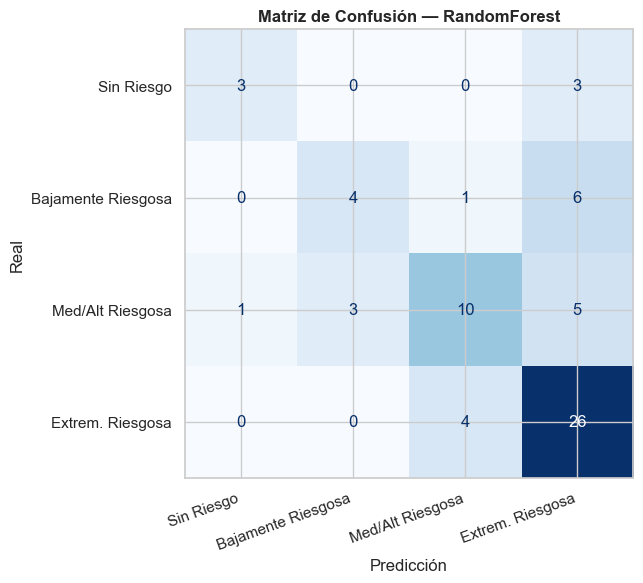


[[ 3  0  0  3]
 [ 0  4  1  6]
 [ 1  3 10  5]
 [ 0  0  4 26]]


In [11]:
# ============================================================
# PASO 6 — MATRIZ DE CONFUSIÓN
# ============================================================

y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_LABELS,
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"Matriz de Confusión — {best_name}", fontweight="bold")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

fig.savefig(FIG_DIR / "confusion_matrix_best.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"\n{cm}")


---
## PASO 7 — Feature importance (Random Forest)

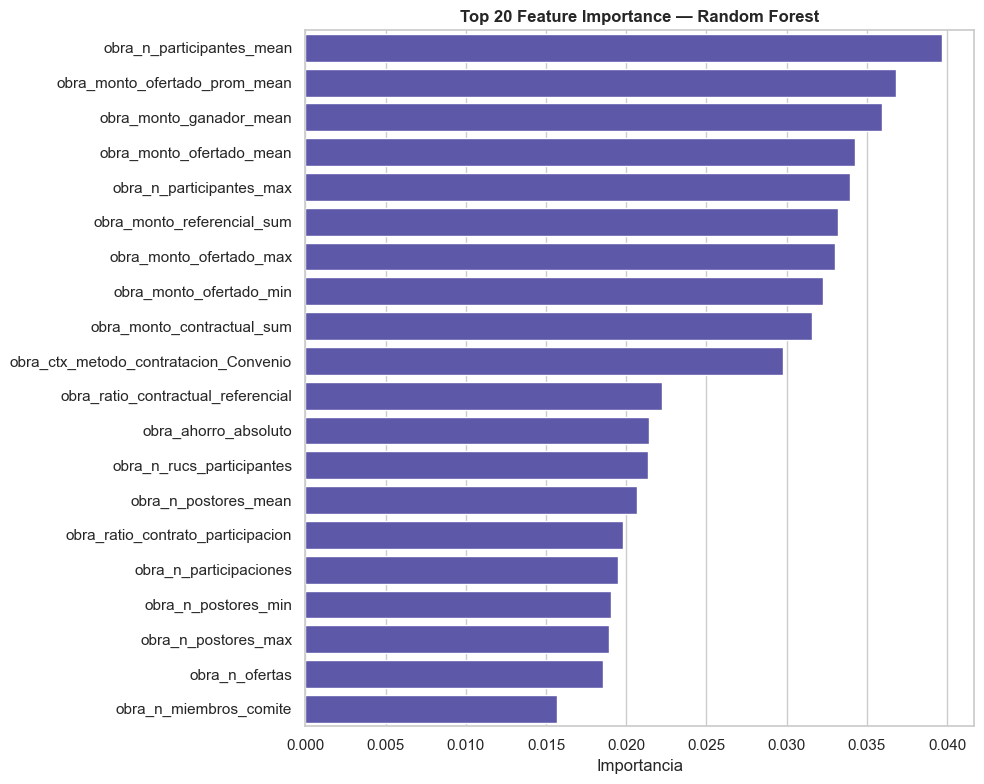

,feature,importance
0,obra_n_participantes_mean,0.0397
1,obra_monto_ofertado_prom_mean,0.0368
2,obra_monto_ganador_mean,0.0359
3,obra_monto_ofertado_mean,0.0343
4,obra_n_participantes_max,0.0339
5,obra_monto_referencial_sum,0.0332
6,obra_monto_ofertado_max,0.0330
7,obra_monto_ofertado_min,0.0323
8,obra_monto_contractual_sum,0.0316
9,obra_ctx_metodo_contratacion_Convenio,0.0298



✅ Feature importance exportada


In [12]:
# ============================================================
# PASO 7 — FEATURE IMPORTANCE
# ============================================================

rf_pipe = trained_pipelines["RandomForest"]

# Nombres de features tras el preprocesador
raw_names  = rf_pipe.named_steps["prep"].get_feature_names_out()

# Limpiar prefijos num__ y cat__
clean_names = [
    n.replace("num__", "").replace("cat__", "")
    for n in raw_names
]

importances = rf_pipe.named_steps["model"].feature_importances_

fi_df = (
    pd.DataFrame({"feature": clean_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

TOP_N   = 20
top_fi  = fi_df.head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top_fi, x="importance", y="feature", ax=ax, color="#534AB7")
ax.set_title(f"Top {TOP_N} Feature Importance — Random Forest", fontweight="bold")
ax.set_xlabel("Importancia")
ax.set_ylabel("")
plt.tight_layout()

fig.savefig(FIG_DIR / "feature_importance_rf.png", dpi=300, bbox_inches="tight")
plt.show()

display(top_fi)

# Exportar CSV completo
fi_df.to_csv(MODEL_DIR / "feature_importance_rf_obra_v4.csv", index=False, encoding="utf-8-sig")
print("\n✅ Feature importance exportada")


---
## PASO 8 — Cross Validation (CV-5 estratificado)

In [13]:
# ============================================================
# PASO 8 — CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1":          "f1_macro",
    "weighted_f1":       "f1_weighted",
}

cv_results = []

for name, clf in models.items():

    print(f"\nCV — {name}")

    pipe = Pipeline([("prep", preprocessor), ("model", clf)])

    scores = cross_validate(
        pipe, X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    row = {"modelo": name}
    for metric in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]:
        vals = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = vals.mean()
        row[f"{metric}_std"]  = vals.std()

    cv_results.append(row)
    print(f"  macro_f1 : {row['macro_f1_mean']:.4f} ± {row['macro_f1_std']:.4f}")
    print(f"  bal_acc  : {row['balanced_accuracy_mean']:.4f} ± {row['balanced_accuracy_std']:.4f}")

cv_df = pd.DataFrame(cv_results).sort_values("macro_f1_mean", ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("RESULTADOS CROSS VALIDATION")
print("="*60)
display(cv_df)



CV — RandomForest
  macro_f1 : 0.5953 ± 0.0792
  bal_acc  : 0.5746 ± 0.0685

CV — GradientBoosting
  macro_f1 : 0.5887 ± 0.0475
  bal_acc  : 0.5746 ± 0.0336

CV — LogisticRegression
  macro_f1 : 0.5105 ± 0.0427
  bal_acc  : 0.5230 ± 0.0455

CV — LightGBM
  macro_f1 : 0.5759 ± 0.0768
  bal_acc  : 0.5700 ± 0.0742

RESULTADOS CROSS VALIDATION


,modelo,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,RandomForest,0.6745,0.0644,0.5746,0.0685,0.5953,0.0792,0.6530,0.0717
1,GradientBoosting,0.6563,0.0356,0.5746,0.0336,0.5887,0.0475,0.6488,0.0308
2,LightGBM,0.6472,0.0554,0.5700,0.0742,0.5759,0.0768,0.6447,0.0531
3,LogisticRegression,0.5795,0.0437,0.5230,0.0455,0.5105,0.0427,0.5853,0.0369


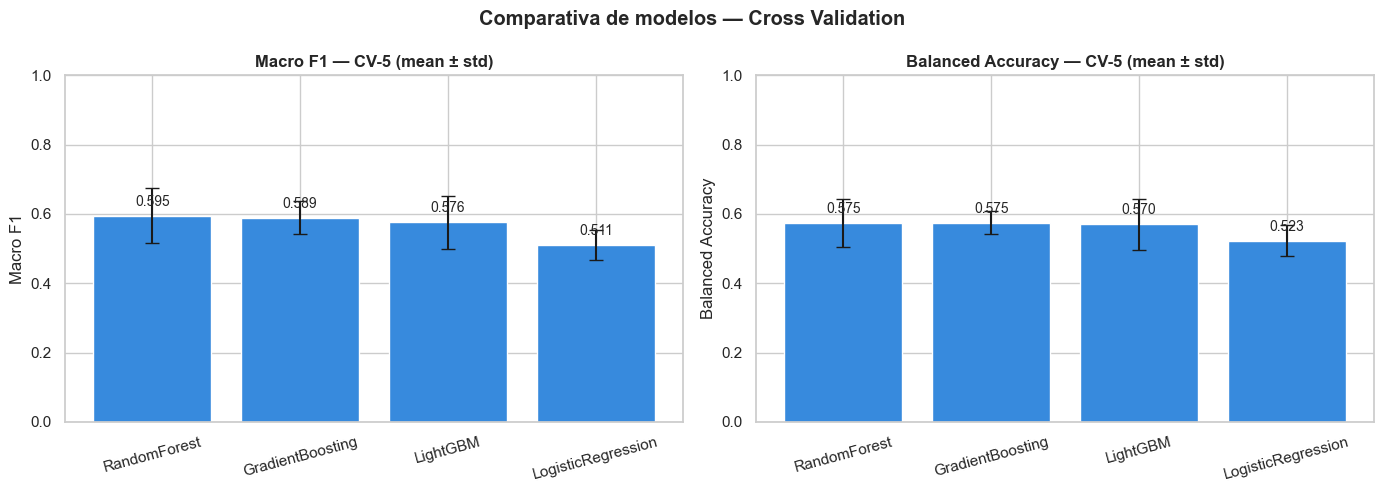

In [14]:
# ============================================================
# PASO 8.1 — GRÁFICO COMPARATIVO CV
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in [
    (axes[0], "macro_f1",          "Macro F1"),
    (axes[1], "balanced_accuracy", "Balanced Accuracy"),
]:
    bars = ax.bar(
        cv_df["modelo"],
        cv_df[f"{metric}_mean"],
        yerr=cv_df[f"{metric}_std"],
        capsize=5,
        color="#378ADD",
        edgecolor="white",
    )
    ax.set_title(f"{label} — CV-5 (mean ± std)", fontweight="bold")
    ax.set_ylabel(label)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=15)

    for bar, val in zip(bars, cv_df[f"{metric}_mean"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=10,
        )

plt.suptitle("Comparativa de modelos — Cross Validation", fontweight="bold")
plt.tight_layout()
fig.savefig(FIG_DIR / "model_comparison_cv.png", dpi=300, bbox_inches="tight")
plt.show()


---
## PASO 9 — Hyperparameter Tuning (Random Forest)

In [15]:
# ============================================================
# PASO 9 — HYPERPARAMETER TUNING RF
# n_iter=50 para mayor cobertura del espacio de búsqueda
# ============================================================

rf_pipeline = Pipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

param_dist = {
    "model__n_estimators":      randint(100, 800),
    "model__max_depth":         [None, 5, 10, 15, 20, 30],
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf":  randint(1, 10),
    "model__max_features":      ["sqrt", "log2", None],
    "model__bootstrap":         [True, False],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_search.fit(X_train, y_train)

print("\n✅ Tuning finalizado")
print(f"   Mejor score CV (macro F1): {rf_search.best_score_:.4f}")
print(f"\n   Mejores parámetros:")
for k, v in rf_search.best_params_.items():
    print(f"   {k:35s}: {v}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Tuning finalizado
   Mejor score CV (macro F1): 0.5901

   Mejores parámetros:
   model__bootstrap                   : False
   model__max_depth                   : 30
   model__max_features                : log2
   model__min_samples_leaf            : 3
   model__min_samples_split           : 13
   model__n_estimators                : 666


---
## PASO 10 — Evaluación final RF Tuned

In [16]:
# ============================================================
# PASO 10 — EVALUACIÓN FINAL RF TUNED
# ============================================================

best_rf    = rf_search.best_estimator_
y_pred_rf  = best_rf.predict(X_test)

acc    = accuracy_score(y_test, y_pred_rf)
bal    = balanced_accuracy_score(y_test, y_pred_rf)
mac_f1 = f1_score(y_test, y_pred_rf, average="macro",    zero_division=0)
wei_f1 = f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)

print("=" * 60)
print("RESULTADOS RF TUNED — TEST SET")
print("=" * 60)
print(f"  Accuracy           : {acc:.4f}")
print(f"  Balanced Accuracy  : {bal:.4f}")
print(f"  Macro F1           : {mac_f1:.4f}")
print(f"  Weighted F1        : {wei_f1:.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    y_test, y_pred_rf,
    target_names=CLASS_LABELS,
    zero_division=0,
))


RESULTADOS RF TUNED — TEST SET
  Accuracy           : 0.6667
  Balanced Accuracy  : 0.5581
  Macro F1           : 0.5804
  Weighted F1        : 0.6431

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

        Sin Riesgo       0.75      0.50      0.60         6
Bajamente Riesgosa       0.43      0.27      0.33        11
  Med/Alt Riesgosa       0.67      0.53      0.59        19
  Extrem. Riesgosa       0.70      0.93      0.80        30

          accuracy                           0.67        66
         macro avg       0.64      0.56      0.58        66
      weighted avg       0.65      0.67      0.64        66



In [17]:
# ============================================================
# PASO 10.1 — COMPARATIVA BASELINE vs TUNED
# ============================================================

baseline_f1 = results_df[results_df["modelo"] == "RandomForest"]["macro_f1"].values[0]
mejora      = (mac_f1 - baseline_f1) / baseline_f1 * 100

print(f"Macro F1 baseline RF  : {baseline_f1:.4f}")
print(f"Macro F1 RF tuned     : {mac_f1:.4f}")
print(f"Mejora relativa       : {mejora:+.1f}%")


Macro F1 baseline RF  : 0.5939
Macro F1 RF tuned     : 0.5804
Mejora relativa       : -2.3%


---
## PASO 11 — Guardar modelo y métricas

In [18]:
# ============================================================
# PASO 11 — EXPORTAR MODELO, MÉTRICAS Y FEATURE IMPORTANCE
# ============================================================

final_model   = rf_search.best_estimator_
y_pred_final  = final_model.predict(X_test)

# ── Métricas ──────────────────────────────────────────────────
metrics = {
    "model_name":        "RandomForest_obra_v4_tuned",
    "dataset":           "obra_v4_4niveles",
    "target_strategy":   "4 niveles (Decisión D1)",
    "n_features":        int(X_train.shape[1]),
    "n_train":           int(X_train.shape[0]),
    "n_test":            int(X_test.shape[0]),
    "accuracy":          float(accuracy_score(y_test, y_pred_final)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred_final)),
    "macro_f1":          float(f1_score(y_test, y_pred_final, average="macro",    zero_division=0)),
    "weighted_f1":       float(f1_score(y_test, y_pred_final, average="weighted", zero_division=0)),
    "cv_macro_f1_mean":  float(rf_search.best_score_),
    "best_params":       rf_search.best_params_,
    "class_labels":      CLASS_LABELS,
}

# ── Guardar modelo ────────────────────────────────────────────
MODEL_PATH   = MODEL_DIR / "pipeline_rf_obra_v4.pkl"
METRICS_PATH = MODEL_DIR / "metrics_rf_obra_v4.json"

joblib.dump(final_model, MODEL_PATH)

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, default=str)

# ── Feature importance ────────────────────────────────────────
raw_names   = final_model.named_steps["prep"].get_feature_names_out()
clean_names = [n.replace("num__","").replace("cat__","") for n in raw_names]
importances = final_model.named_steps["model"].feature_importances_

fi_final = (
    pd.DataFrame({"feature": clean_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

IMPORTANCE_PATH = MODEL_DIR / "feature_importance_rf_obra_v4.csv"
fi_final.to_csv(IMPORTANCE_PATH, index=False, encoding="utf-8-sig")

print("=" * 60)
print("ARTEFACTOS EXPORTADOS")
print("=" * 60)
print(f"  Modelo            : {MODEL_PATH}")
print(f"  Métricas          : {METRICS_PATH}")
print(f"  Feature importance: {IMPORTANCE_PATH}")
print()
display(pd.DataFrame([{k: v for k, v in metrics.items() if k != "best_params"}]))


ARTEFACTOS EXPORTADOS
  Modelo            : C:\IA_Investigacion\Deteccion_Corrupcion\models\obra_v4\pipeline_rf_obra_v4.pkl
  Métricas          : C:\IA_Investigacion\Deteccion_Corrupcion\models\obra_v4\metrics_rf_obra_v4.json
  Feature importance: C:\IA_Investigacion\Deteccion_Corrupcion\models\obra_v4\feature_importance_rf_obra_v4.csv



,model_name,dataset,target_strategy,n_features,n_train,n_test,accuracy,balanced_accuracy,macro_f1,weighted_f1,cv_macro_f1_mean,class_labels
0,RandomForest_obra_v4_tuned,obra_v4_4niveles,4 niveles (Decisión D1),77,260,66,0.6667,0.5581,0.5804,0.6431,0.5901,"[Sin Riesgo, Bajamente Riesgosa, Med/Alt Riesg..."


---
## PASO 12 — Gráficos finales

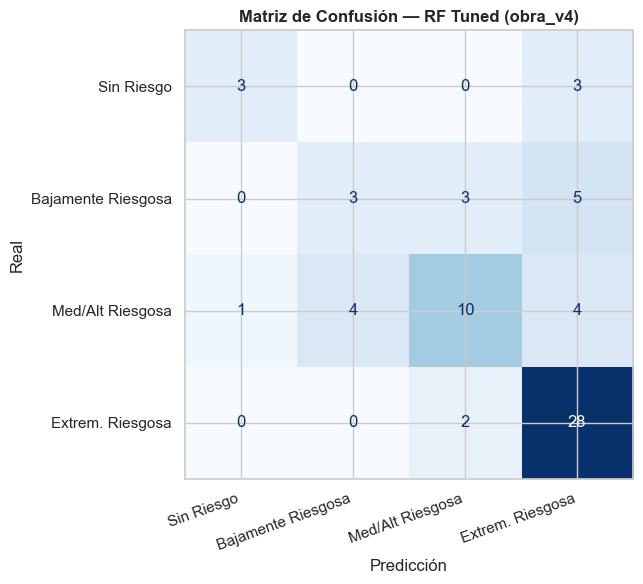

In [19]:
# ============================================================
# PASO 12.1 — MATRIZ DE CONFUSIÓN RF TUNED
# ============================================================

cm_tuned = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=CLASS_LABELS,
).plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title("Matriz de Confusión — RF Tuned (obra_v4)", fontweight="bold")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

fig.savefig(FIG_DIR / "confusion_matrix_rf_tuned.png", dpi=300, bbox_inches="tight")
plt.show()


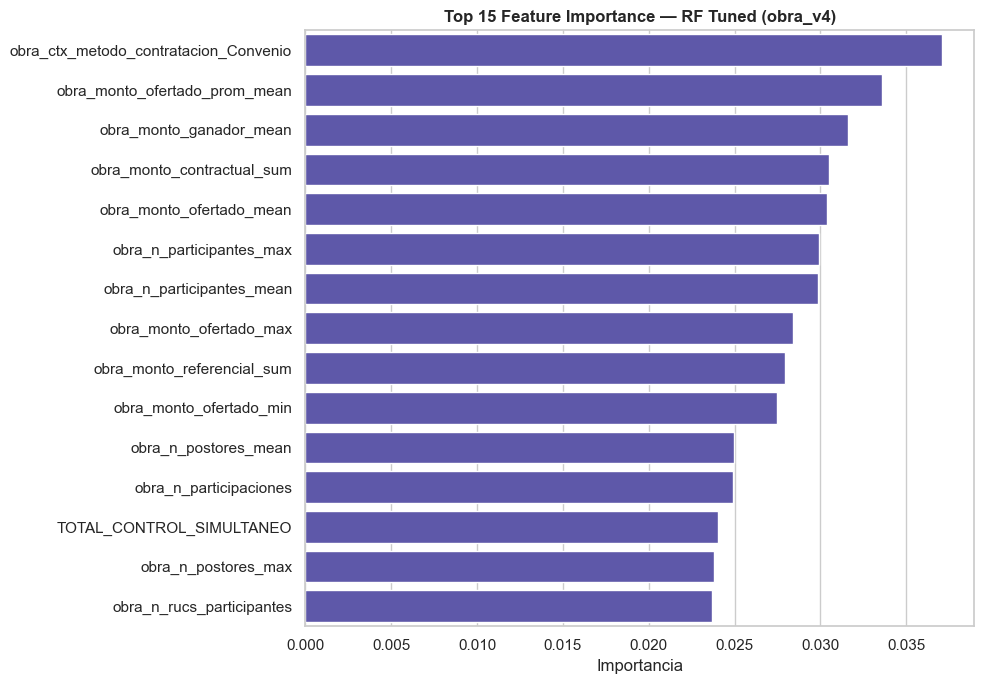

,feature,importance
0,obra_ctx_metodo_contratacion_Convenio,0.0371
1,obra_monto_ofertado_prom_mean,0.0336
2,obra_monto_ganador_mean,0.0316
3,obra_monto_contractual_sum,0.0305
4,obra_monto_ofertado_mean,0.0304
5,obra_n_participantes_max,0.0299
6,obra_n_participantes_mean,0.0298
7,obra_monto_ofertado_max,0.0284
8,obra_monto_referencial_sum,0.0279
9,obra_monto_ofertado_min,0.0274


In [20]:
# ============================================================
# PASO 12.2 — FEATURE IMPORTANCE TOP 15 (RF TUNED)
# ============================================================

top15 = fi_final.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top15, x="importance", y="feature", ax=ax, color="#534AB7")
ax.set_title("Top 15 Feature Importance — RF Tuned (obra_v4)", fontweight="bold")
ax.set_xlabel("Importancia")
ax.set_ylabel("")
plt.tight_layout()

fig.savefig(FIG_DIR / "feature_importance_rf_tuned.png", dpi=300, bbox_inches="tight")
plt.show()

display(top15)


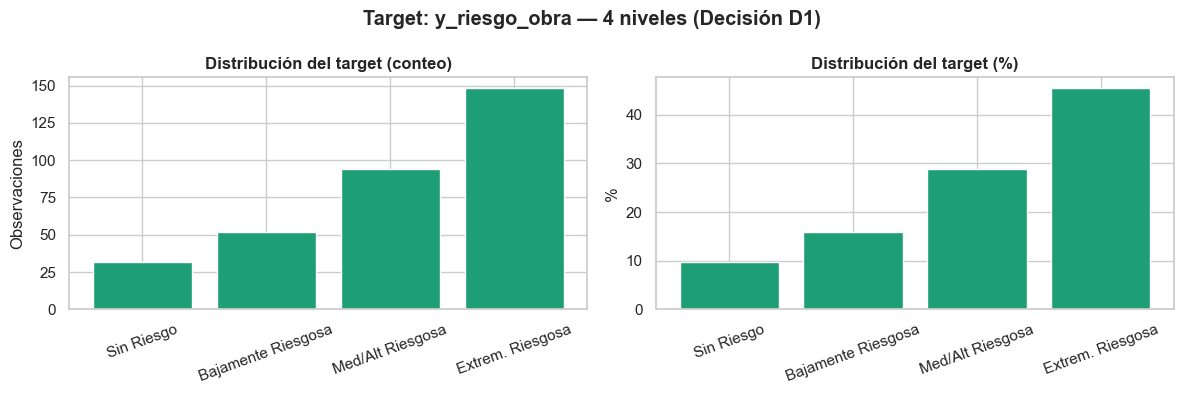

In [21]:
# ============================================================
# PASO 12.3 — DISTRIBUCIÓN DEL TARGET
# ============================================================

vc = y.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(CLASS_LABELS, vc.values, color="#1D9E75", edgecolor="white")
axes[0].set_title("Distribución del target (conteo)", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylabel("Observaciones")

axes[1].bar(CLASS_LABELS, vc.values / vc.sum() * 100, color="#1D9E75", edgecolor="white")
axes[1].set_title("Distribución del target (%)", fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylabel("%")

plt.suptitle("Target: y_riesgo_obra — 4 niveles (Decisión D1)", fontweight="bold")
plt.tight_layout()
fig.savefig(FIG_DIR / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ============================================================
# PASO 12.4 — COMPARATIVA MODELOS (hold-out + CV)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hold-out
axes[0].bar(
    results_df["modelo"],
    results_df["macro_f1"],
    color="#378ADD", edgecolor="white",
)
axes[0].set_title("Macro F1 — Hold-out test", fontweight="bold")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(results_df["macro_f1"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# CV
axes[1].bar(
    cv_df["modelo"],
    cv_df["macro_f1_mean"],
    yerr=cv_df["macro_f1_std"],
    capsize=5,
    color="#D85A30", edgecolor="white",
)
axes[1].set_title("Macro F1 — CV-5 (mean ± std)", fontweight="bold")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(cv_df["macro_f1_mean"]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

plt.suptitle("Comparativa de modelos — obra_v4", fontweight="bold")
plt.tight_layout()
fig.savefig(FIG_DIR / "model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Resumen y siguientes pasos

In [22]:
# ============================================================
# RESUMEN FINAL
# ============================================================

print("=" * 60)
print("RESUMEN NOTEBOOK 03 — obra_v4")
print("=" * 60)
print(f"  Dataset          : 326 obs × {X.shape[1]} features")
print(f"  Target           : 4 niveles (Decisión D1)")
print(f"  Mejor modelo     : {best_name} (hold-out)")
print(f"  Macro F1 baseline: {baseline_f1:.4f}")
print(f"  Macro F1 tuned   : {mac_f1:.4f}  ({mejora:+.1f}%)")
print(f"  Bal. Accuracy    : {bal:.4f}")
print()
print("Artefactos generados:")
print(f"  models/obra_v4/pipeline_rf_obra_v4.pkl")
print(f"  models/obra_v4/metrics_rf_obra_v4.json")
print(f"  models/obra_v4/feature_importance_rf_obra_v4.csv")
print(f"  reports/figures/confusion_matrix_rf_tuned.png")
print(f"  reports/figures/feature_importance_rf_tuned.png")
print(f"  reports/figures/model_comparison.png")
print(f"  reports/figures/target_distribution.png")
print()
print("Siguientes pasos:")
print("  → Sprint 3: incorporar dataset empresa + funcionario")
print("  → SHAP explainability")
print("  → Detección de redes de riesgo")
print("  → API de inferencia")


RESUMEN NOTEBOOK 03 — obra_v4
  Dataset          : 326 obs × 77 features
  Target           : 4 niveles (Decisión D1)
  Mejor modelo     : RandomForest (hold-out)
  Macro F1 baseline: 0.5939
  Macro F1 tuned   : 0.5804  (-2.3%)
  Bal. Accuracy    : 0.5581

Artefactos generados:
  models/obra_v4/pipeline_rf_obra_v4.pkl
  models/obra_v4/metrics_rf_obra_v4.json
  models/obra_v4/feature_importance_rf_obra_v4.csv
  reports/figures/confusion_matrix_rf_tuned.png
  reports/figures/feature_importance_rf_tuned.png
  reports/figures/model_comparison.png
  reports/figures/target_distribution.png

Siguientes pasos:
  → Sprint 3: incorporar dataset empresa + funcionario
  → SHAP explainability
  → Detección de redes de riesgo
  → API de inferencia
